In [412]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [413]:
df = pd.read_csv("penguins_data.csv")

In [414]:
df

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,46.2,14.5,209.0,4800.0,Gentoo
1,37.3,20.5,199.0,3775.0,Adelie
2,39.6,20.7,191.0,3900.0,Adelie
3,44.1,19.7,196.0,4400.0,Adelie
4,41.5,18.3,195.0,4300.0,Adelie
...,...,...,...,...,...
116,47.5,14.0,212.0,4875.0,Gentoo
117,48.7,14.1,210.0,4450.0,Gentoo
118,36.2,17.3,187.0,3300.0,Adelie
119,37.2,18.1,178.0,3900.0,Adelie


In [415]:
# Viewing the data before cleaning
print(df.shape)
df.info()
df.describe()

(121, 5)
<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     120 non-null    float64
 1   bill_depth_mm      121 non-null    float64
 2   flipper_length_mm  121 non-null    float64
 3   body_mass_g        121 non-null    float64
 4   species            121 non-null    str    
dtypes: float64(4), str(1)
memory usage: 5.6 KB


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,120.000000,121.000000,121.000000,121.000000
mean,43.543333,16.948760,200.008264,4152.892562
std,5.502768,3.694097,14.039525,807.247058
min,34.100000,-17.000000,174.000000,2850.000000
25%,38.850000,15.700000,189.000000,3450.000000
50%,43.200000,17.300000,196.000000,4000.000000
75%,48.425000,18.900000,210.000000,4725.000000
max,55.100000,21.500000,231.000000,5850.000000


In [416]:
# Finding the amount of duplicated rows
print(df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

bill_length_mm       1
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
species              0
dtype: int64

Duplicated rows: 1


In [417]:
# Finding the amount of unique species that might be misnamed
df["species"].unique()

<ArrowStringArray>
['Gentoo', 'Adelie', 'Chinstrap', 'ADELIE', '  Chinstrap', 'Aaadelie']
Length: 6, dtype: str

In [418]:
# Taking the current species and removing spacing and putting them all to lowercase
df["species"] = df["species"].astype(str).str.strip().str.lower()
# Renaming a species with the wrong spelling to the correct one
species_corrections = {"aaadelie": "adelie"}
df["species"] = df["species"].replace(species_corrections)

In [419]:
# checking current species again
df["species"].unique()

<ArrowStringArray>
['gentoo', 'adelie', 'chinstrap']
Length: 3, dtype: str

In [420]:
# dropping duplicates and reviewing if they got successfully removed
df = df.drop_duplicates().copy()

df.shape

(120, 5)

In [421]:
# checking the amount of null values remaining
df.isnull().sum()

bill_length_mm       1
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
species              0
dtype: int64

In [422]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
# Replace non-positive values with NaN
for col in numeric_cols:
    df.loc[df[col] <= 0, col] = np.nan

In [423]:
# rechecking if any new null values have been created
df.isnull().sum()

bill_length_mm       1
bill_depth_mm        1
flipper_length_mm    0
body_mass_g          0
species              0
dtype: int64

In [424]:
# viewing the rows that have null values
df[df.isnull().any(axis=1)]

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
12,NaN,14.2,209.0,4600.0,gentoo
49,36.4,NaN,195.0,3325.0,adelie


In [425]:
# Fill missing numeric values using species-based median
for col in numeric_cols:
    df[col] = df.groupby("species")[col].transform(lambda x: x.fillna(x.median()))

In [426]:
# Printing All Cleaned up changes
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())
print("\species counts:")
print(df["species"].value_counts())

df.describe()
# Saving cleaned dataset to speperate csv file.
df.to_csv('cleanedPenguinDataset.csv', index=False)

Missing values:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
species              0
dtype: int64

Duplicated rows: 0
\species counts:
species
adelie       59
gentoo       41
chinstrap    20
Name: count, dtype: int64


In [427]:
dfbin["bill_length_mm_bin"].value_counts().sort_index()

bill_length_mm_bin
short     49
medium    41
long      30
Name: count, dtype: int64

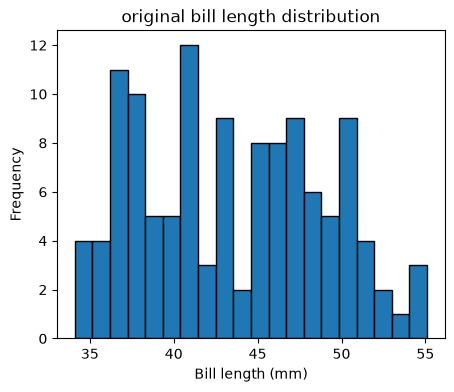

count    120.000000
mean      43.509167
std        5.465553
min       34.100000
25%       38.850000
50%       43.200000
75%       47.800000
max       55.100000
Name: bill_length_mm, dtype: float64

In [428]:
# Plotting the ditribution of Bill Length
plt.figure(figsize=(5,4))
plt.hist(df["bill_length_mm"], bins=20, edgecolor="black")
plt.xlabel("Bill length (mm)")
plt.ylabel("Frequency")
plt.axis()
plt.title("original bill length distribution")
plt.show()
df["bill_length_mm"].describe()

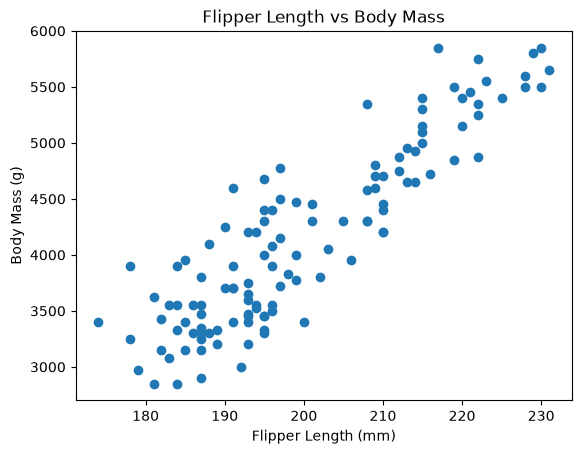

In [429]:
# Creating a scatter plot of Flipper Length vs Body Mass
plt.scatter(df["flipper_length_mm"], df["body_mass_g"])

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Flipper Length vs Body Mass")

plt.show()

In [430]:
# Separate the inputs (X_penguin) and the label (y_penguin)
X_penguin = df[numeric_cols]
y_penguin = df["species"]

print(X_penguin.shape, y_penguin.shape)

(120, 4) (120,)


In [431]:
# Standardise the inputs with StandardScaler
penguin_scaler = StandardScaler()
penguin_scaler.fit(X_penguin)
X_penguin_scaled = penguin_scaler.transform(X_penguin)

In [432]:
# Check the mean and standard deviation of each standardised column
X_penguin_scaled_df = pd.DataFrame(X_penguin_scaled, columns=numeric_cols)

X_penguin_scaled_df.agg(["mean", "std"]).round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
mean,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


In [433]:
# Fit PCA on the standardised data and transform it
penguin_pca = PCA(n_components=None)
penguin_pca.fit(X_penguin_scaled)
penguin_scores = penguin_pca.transform(X_penguin_scaled)

print("Explained-variance ratio:", penguin_pca.explained_variance_ratio_.round(4))
print("Shape of the scores:", penguin_scores.shape)

Explained-variance ratio: [0.7004 0.1927 0.0858 0.0211]
Shape of the scores: (120, 4)


In [434]:
print("Explained-variance ratio:", penguin_pca.explained_variance_ratio_.round(4))

Explained-variance ratio: [0.7004 0.1927 0.0858 0.0211]


In [435]:
# Individual and cumulative contribution of each component
penguin_individual = penguin_pca.explained_variance_ratio_
penguin_cumulative = np.cumsum(penguin_individual)

penguin_contribution = pd.DataFrame({
    "component": ["PC1", "PC2", "PC3", "PC4"],
    "individual_contribution": penguin_individual,
    "cumulative_contribution": penguin_cumulative
})

penguin_contribution.round(4)

,component,individual_contribution,cumulative_contribution
0,PC1,0.7004,0.7004
1,PC2,0.1927,0.8930
2,PC3,0.0858,0.9789
3,PC4,0.0211,1.0000


In [436]:
# Loadings: rows = original features, columns = components
penguin_loadings = pd.DataFrame(
    penguin_pca.components_.T,
    index=numeric_cols,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

penguin_loadings.round(3)

,PC1,PC2,PC3,PC4
bill_length_mm,0.461,0.574,0.659,-0.155
bill_depth_mm,-0.394,0.813,-0.392,0.174
flipper_length_mm,0.576,0.004,-0.222,0.786
body_mass_g,0.548,0.097,-0.602,-0.572


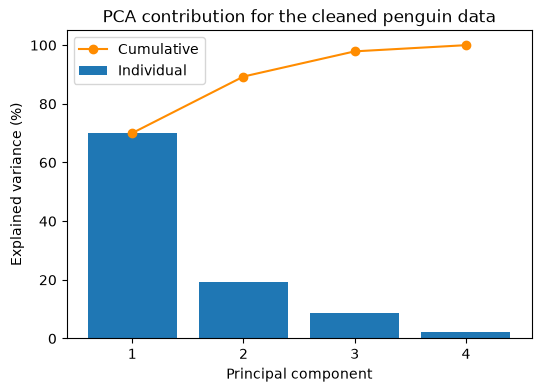

In [437]:
# Bar chart of individual contributions with a cumulative line
component_numbers = np.arange(1, 5)

plt.figure(figsize=(6, 4))
plt.bar(component_numbers, penguin_individual * 100, label="Individual")
plt.plot(component_numbers, penguin_cumulative * 100, marker="o", color="darkorange", label="Cumulative")

plt.xticks(component_numbers)
plt.ylim(0, 105)
plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA contribution for the cleaned penguin data")
plt.legend()
plt.show()

In [438]:
# Keep three components and store the result in a DataFrame
penguin_pca3 = PCA(n_components=3)
penguin_scores_3 = penguin_pca3.fit_transform(X_penguin_scaled)

df_pca = pd.DataFrame(penguin_scores_3, columns=["PC1", "PC2", "PC3"])
df_pca["species"] = y_penguin.to_numpy()

print(df_pca.shape)
df_pca.head()

(120, 4)


,PC1,PC2,PC3,species
0,1.571112,-0.750982,0.242643,gentoo
1,-1.483309,0.635016,-1.089699,adelie
2,-1.572646,0.972209,-0.817442,adelie
3,-0.446327,1.100509,-0.530222,adelie
4,-0.498227,0.241422,-0.477904,adelie


In [439]:
# Save the three-component representation
df_pca.to_csv("penguinTransformedDataset.csv", index=False)

print("PCA result saved.")

PCA result saved.
